# Logistic Regression

This notebook applies Logistic Regression to predict whether a basketball player 
is a good free throw shooter (GoodFT).

The model is trained on the cleaned dataset and evaluated using classification metrics.

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("cleaned_data.csv")

df.head()

,Age,MP,G,GS,FG%,3P%,2P%,eFG%,FTA,PTS,AST,TRB,TOV,GoodFT,Pos_F,Pos_PF,Pos_PG,Pos_SF,Pos_SG
0,23.0,43.2,82.0,7.0,0.512,0.311,0.475,0.484,9.7,34.5,2.2,14.1,1.0,1,False,False,False,False,False
1,30.0,40.4,80.0,7.0,0.464,0.311,0.475,0.484,5.5,30.6,6.2,5.7,1.0,1,False,False,False,True,False
2,27.0,42.3,65.0,7.0,0.513,0.311,0.475,0.484,6.6,30.0,4.1,14.0,1.0,0,False,False,False,False,False
3,26.0,39.6,82.0,7.0,0.456,0.311,0.475,0.484,9.1,26.5,6.8,2.7,1.0,1,False,False,True,False,False
4,26.0,37.6,69.0,7.0,0.441,0.311,0.475,0.484,5.1,24.3,4.5,4.0,1.0,0,False,False,True,False,False


In [28]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred = model.predict(X_test_scaled)

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7558471192241871


In [34]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.92      0.84      3693
           1       0.66      0.37      0.48      1566

    accuracy                           0.76      5259
   macro avg       0.72      0.65      0.66      5259
weighted avg       0.74      0.76      0.73      5259



In [35]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[3393  300]
 [ 984  582]]


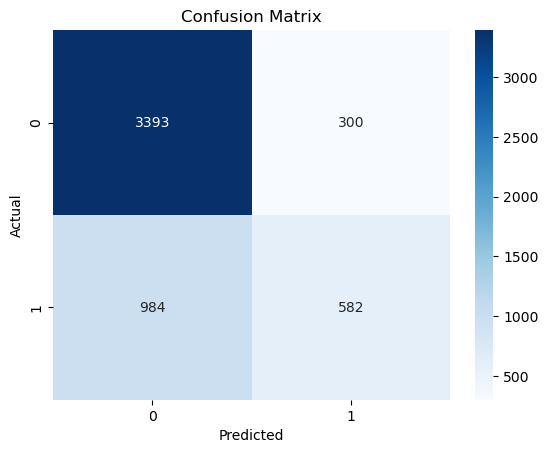

In [36]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

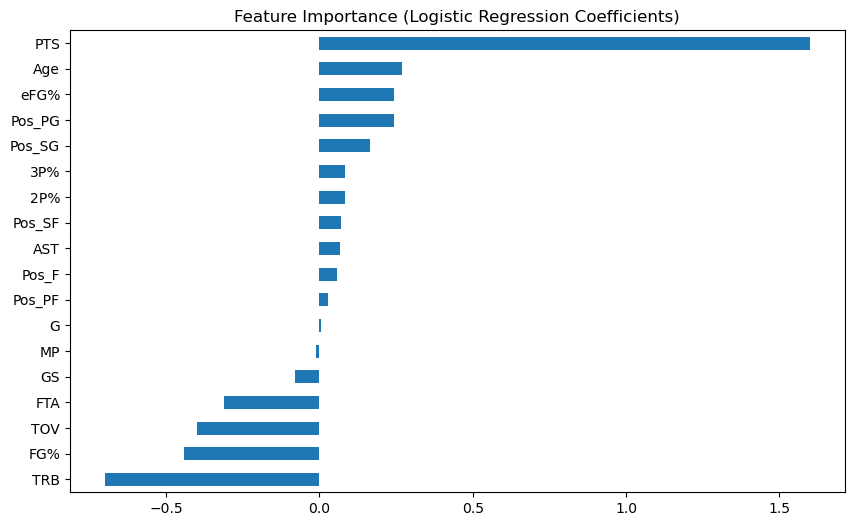

In [37]:
coefficients = pd.Series(model.coef_[0], index=X.columns)

coefficients.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()